In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train = np.load("../data/b_cb/processed/dataset_train_shortened_bcb.npz", allow_pickle=True)
X_train = train["X"]
y_train = train["y"]          # int {0,1}

full = np.load("../data/b_cb/processed/dataset_full_bcb.npz", allow_pickle=True)
X_full = full["X"]
Delta_full = full["Delta"]


In [3]:
print("Number of features:", X_full.shape[1])
print("TRAIN", y_train.shape)
print(X_train.shape)

Number of features: 30
TRAIN (8156,)
(8156, 30)


In [4]:
def run_supervised_pipeline(model, X_train, y_train, X_full):
    """
    Train a supervised classifier on deep-phase data and
    evaluate its probabilistic predictions on the full dataset.

    Returns:
        train_score : training accuracy (sanity check only)
        P_Cb         : predicted probability of phase Cb for all samples
    """

    # Fit the model on deep phase A/C training data
    model.fit(X_train, y_train)

    # Training accuracy (used only as a consistency check;
    # not used to assess the phase transition)
    train_score = model.score(X_train, y_train)

    # Obtain probabilistic predictions for the full dataset
    if hasattr(model, "predict_proba"):
        # Preferred case: model provides calibrated probabilities
        P_Cb = model.predict_proba(X_full)[:, 1]
    else:
        # Fallback: map decision function scores to (0,1) via sigmoid
        #barely ever it happens
        scores = model.decision_function(X_full)
        P_Cb = 1.0 / (1.0 + np.exp(-scores))

    return train_score, P_Cb


In [5]:
def mean_and_susceptibility_vs_delta(P_Cb, Delta_full):
    """
    Compute the mean phase-B probability and its susceptibility χ
    as a function of delta.

    χ is defined as the variance of Pr(B) at fixed delta.

    Returns:
        mean_P_Cb : ⟨Pr(Cb)⟩(delta)
        chi_P_Cb : χ(delta)
    """

    # Assemble predictions and κ₀ values into a DataFrame
    df = pd.DataFrame({
        "Delta": Delta_full,
        "P_Cb": P_Cb   # convert Pr(A) -> Pr(B)
    })

    # Group by κ₀
    grouped = df.groupby("Delta")["P_Cb"]

    # Mean phase-C probability
    mean_P_Cb = grouped.mean()

    # Susceptibility (variance of Pr(C))
    chi_P_Cb = grouped.var()

    return mean_P_Cb, chi_P_Cb


In [6]:
def extract_delta_crit(chi_series):
    """
    Extract the critical delta as the location of the maximum
    of the susceptibility χ.

    Returns:
        delta_crit : κ₀ value at which χ is maximal
        chi_max : maximum value of χ
    """
    delta_values = chi_series.index.values
    chi_values = chi_series.values

    idx_max = np.argmax(chi_values)
    return delta_values[idx_max], chi_values[idx_max]


In [7]:
def plot_multi_transition(curves, calibrated=True, title="B–Cb transition"):
    """
    Plot ⟨Pr(Cb)⟩ vs delta for multiple classifiers on the same axes.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    label_key = "calibrated" if calibrated else "uncalibrated"

    # Plot mean phase-Cb probability for each model
    for model_name, model_curves in curves.items():
        mean_P = model_curves[label_key]["mean"]

        ax.plot(
            mean_P.index,
            mean_P.values,
            marker="o",
            linewidth=2,
            label=model_name
        )

    # Highlight expected transition region
    # ax.axvspan(, 4.79, color="gray", alpha=0.2)
    # ax.axvline(4.77, linestyle=":", color="black")

    ax.set_xlabel(r"$\kappa_0$")
    ax.set_ylabel(r"$\langle \mathrm{Pr}(d_j(\kappa_0)\in Cb)\rangle$")
    ax.set_title(
        title + (" (calibrated)" if calibrated else " (uncalibrated)")
    )
    ax.legend()
    ax.grid(True)

    plt.show()


In [8]:
def plot_multi_chi(curves, calibrated=True, title="Susceptibility χ"):
    """
    Plot susceptibility χ(delta) for multiple classifiers.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    label_key = "calibrated" if calibrated else "uncalibrated"

    for model_name, model_curves in curves.items():
        chi = model_curves[label_key]["chi"]

        ax.plot(
            chi.index,
            chi.values,
            linewidth=2,
            label=model_name
        )

    ax.set_xlabel(r"$\kappa_0$")
    ax.set_ylabel(r"$\chi$")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

    plt.show()


In [9]:
def plot_calibration_effect(model_name, curves):
    """
    Compare calibrated vs uncalibrated ⟨Pr(Cb)⟩ curves
    for a single classifier.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    for label, style in [("uncalibrated", "--"), ("calibrated", "-")]:
        mean_P = curves[model_name][label]["mean"]
        ax.plot(
            mean_P.index,
            mean_P.values,
            style,
            label=label,
            linewidth=2
        )

    ax.set_xlabel(r"$\kappa_0$")
    ax.set_ylabel(r"$\langle \mathrm{Pr}(d_j(\kappa_0)\in Cb)\rangle$")
    ax.set_title(f"{model_name}: calibration effect")
    ax.legend()
    ax.grid(True)
    plt.show()



In [10]:
def plot_chi_calibration_effect(model_name, curves):
    """
    Compare calibrated vs uncalibrated susceptibility χ
    for a single classifier.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    for label, style in [("uncalibrated", "--"), ("calibrated", "-")]:
        chi = curves[model_name][label]["chi"]
        ax.plot(
            chi.index,
            chi.values,
            style,
            label=label,
            linewidth=2
        )

    ax.set_xlabel(r"$\kappa_0$")
    ax.set_ylabel(r"$\chi$")
    ax.set_title(f"{model_name}: susceptibility χ")
    ax.legend()
    ax.grid(True)
    plt.show()


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def build_model(base_model, calibrated=True):
    """
    Construct a classifier with optional probability calibration.

    All models are wrapped in a pipeline with feature standardization.
    Logistic Regression is already probabilistic and is not calibrated again.
    """
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", base_model)
    ])

    if not calibrated:
        return pipe

    # Logistic regression already outputs calibrated probabilities
    if isinstance(base_model, LogisticRegression):
        return pipe

    # Apply Platt scaling to obtain calibrated probabilities
    return CalibratedClassifierCV(
        pipe,
        method="sigmoid",
        cv=3
    )



In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=0),
    "Gradient Boosted Trees": GradientBoostingClassifier(random_state=0),
    "kNN": KNeighborsClassifier(n_neighbors=15),
    "SVM (RBF)": SVC(kernel="rbf", probability=True),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(50,50), max_iter=500)
}


In [13]:
# Containers for numerical results and full curves
results = []
curves = {}

# Loop over all classifiers
for name, base_model in models.items():
    print(f"\n=== {name} ===")

    curves[name] = {}

    # Compare uncalibrated vs calibrated versions
    for calibrated in [False, True]:
        label = "calibrated" if calibrated else "uncalibrated"

        model = build_model(base_model, calibrated=calibrated)

        t0 = time.perf_counter()
        train_score, P_Cb = run_supervised_pipeline(
            model, X_train, y_train, X_full
        )
        elapsed = time.perf_counter() - t0

        # Compute ⟨Pr(Cb)⟩, susceptibility χ, and κ₀,crit
        mean_P_Cb, chi_P_Cb = mean_and_susceptibility_vs_delta(P_Cb, Delta_full)
        delta_crit, chi_max = extract_delta_crit(chi_P_Cb)

        # Store curves for plotting
        curves[name][label] = {
            "mean": mean_P_Cb,
            "chi": chi_P_Cb
        }

        # Store numerical summary
        results.append({
            "model": name,
            "calibrated": calibrated,
            "train_accuracy": train_score,
            "delta_crit": delta_crit,
            "chi_max": chi_max,
            "time_sec": elapsed
        })

        print(
            f"{label:12s} | "
            f"acc = {train_score:.5f} | "
            f"delta_crit = {delta_crit:.4f} | "
            f"time = {elapsed:.2f}s"
        )


=== Logistic Regression ===
uncalibrated | acc = 1.00000 | delta_crit = 0.0380 | time = 0.14s
calibrated   | acc = 1.00000 | delta_crit = 0.0380 | time = 0.18s

=== Decision Tree ===
uncalibrated | acc = 1.00000 | delta_crit = 0.0380 | time = 0.14s
calibrated   | acc = 1.00000 | delta_crit = 0.0380 | time = 0.45s

=== Random Forest ===
uncalibrated | acc = 1.00000 | delta_crit = 0.0380 | time = 2.31s
calibrated   | acc = 1.00000 | delta_crit = 0.0380 | time = 6.64s

=== Gradient Boosted Trees ===
uncalibrated | acc = 1.00000 | delta_crit = 0.0380 | time = 2.77s
calibrated   | acc = 1.00000 | delta_crit = 0.0380 | time = 6.58s

=== kNN ===
uncalibrated | acc = 1.00000 | delta_crit = 0.0380 | time = 7.99s
calibrated   | acc = 1.00000 | delta_crit = 0.0380 | time = 18.05s

=== SVM (RBF) ===
uncalibrated | acc = 1.00000 | delta_crit = 0.0380 | time = 0.84s
calibrated   | acc = 1.00000 | delta_crit = 0.0380 | time = 2.07s

=== Neural Network ===
uncalibrated | acc = 1.00000 | delta_crit = 

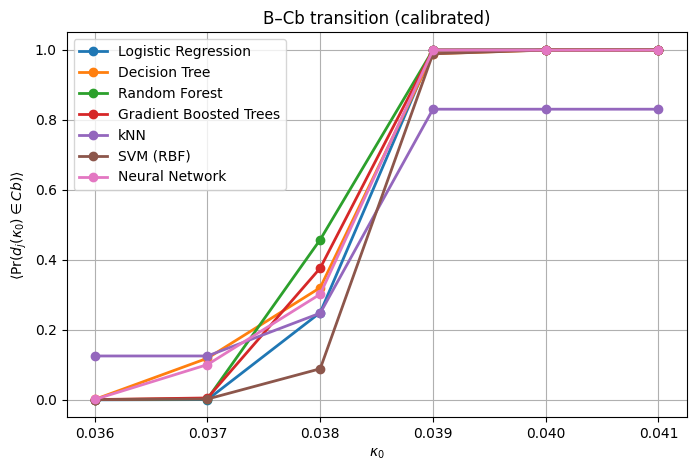

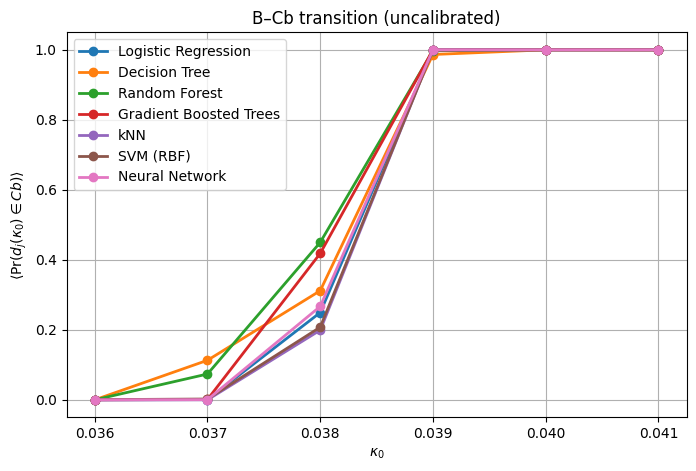

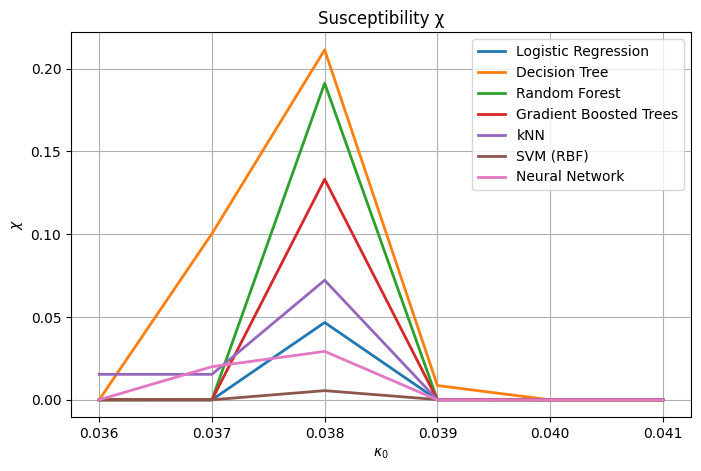

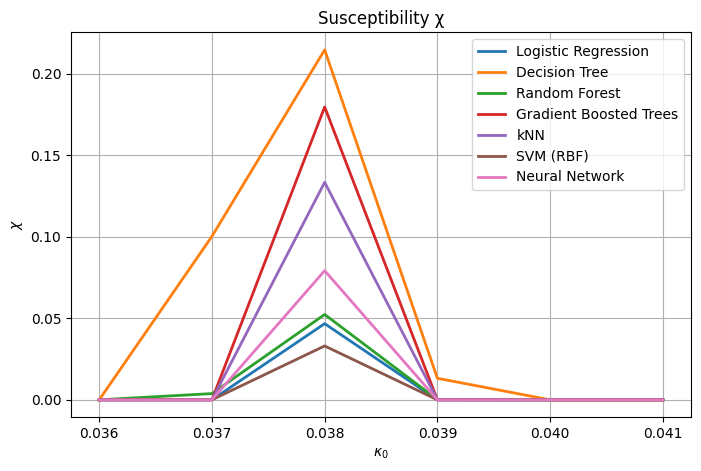

In [14]:
# calibrated curves (paper-faithful)
plot_multi_transition(curves, calibrated=True)

# uncalibrated curves (for comparison)
plot_multi_transition(curves, calibrated=False)

plot_multi_chi(curves, calibrated=True)
plot_multi_chi(curves, calibrated=False)



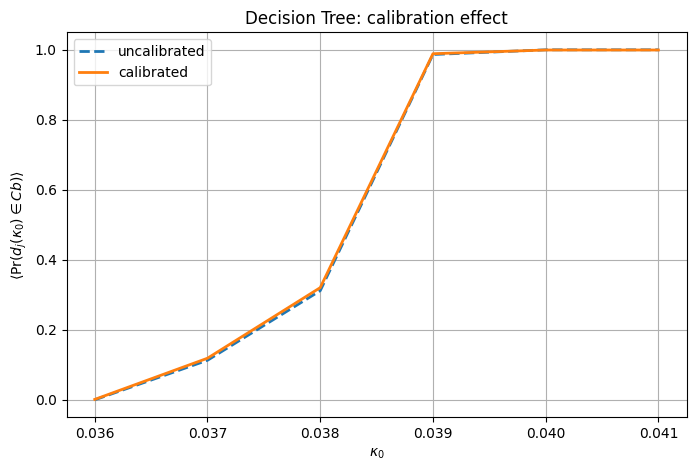

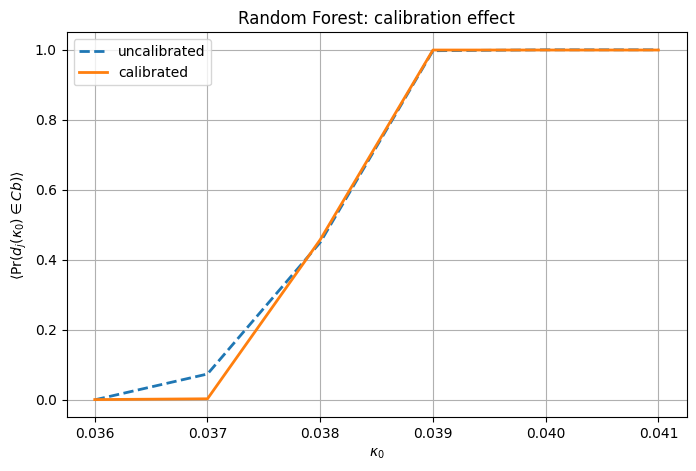

In [15]:
plot_calibration_effect("Decision Tree", curves)
plot_calibration_effect("Random Forest", curves)